<a href="https://colab.research.google.com/github/davidmartinez10-oss/APDR-INFORME-DE-TRANSPORTES-/blob/main/APDR_Caliza_v3_Planificador.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🏭 **SISTEMA DE OPTIMIZACIÓN DE CALIZA v3.0**
## Acerías Paz del Río — Planta Belencito

| Módulo | Contenido |
|---|---|
| **Limpieza** | Fusión duplicados, pipeline de filtrado, tratamiento de outliers con visualización |
| **Simulación** | Monte Carlo 500 datos/proveedor, basado en distribuciones ajustadas |
| **Pronóstico** | Series temporales históricas + predicción por proveedor |
| **Clasificación** | T1 (<1.5%), T2 (<2.5%), T3 (<3.5%), T4 (<5.0%) con perfiles |
| **Mezclas** | Combinaciones exhaustivas para sínter y calcinación |
| **Planificador** | Herramienta interactiva: ingresa llegadas del día → plan de mezcla |

---

## 1. ⚙️ Configuración

In [1]:
!pip install -q scikit-learn xgboost openpyxl matplotlib seaborn plotly scipy

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from scipy import stats
from scipy.optimize import differential_evolution, minimize
from itertools import combinations
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor
from sklearn.linear_model import ElasticNet, Ridge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
try:
    from xgboost import XGBRegressor
    HAS_XGB = True
except: HAS_XGB = False

np.random.seed(42)
plt.style.use('seaborn-v0_8-whitegrid')
C = {'nar':'#E8611A','ama':'#F5A623','neg':'#1A1A1A','g1':'#3D3D3D',
     'g2':'#6B6B6B','t1':'#27AE60','t2':'#F5A623','t3':'#E8611A',
     't4':'#C0392B','azul':'#2980B9','cyan':'#1ABC9C'}
TIPO_COLORS = {'T1-Óptima':C['t1'],'T2-Buena':C['t2'],'T3-Aceptable':C['t3'],'T4-Crítica':C['t4']}
print('✓ Entorno listo')

✓ Entorno listo


## 2. 📂 Carga de Datos

In [2]:
from google.colab import files
print('Selecciona los 2 archivos Excel del proyecto...')
uploaded = files.upload()
fnames = list(uploaded.keys())
PROV_PATH = [f for f in fnames if 'PROVEEDOR' in f.upper() or 'SEGUIMIENTO' in f.upper()]
CAL_PATH = [f for f in fnames if 'CALIDAD' in f.upper() or 'CALES' in f.upper()]
PROV_PATH = PROV_PATH[0] if PROV_PATH else fnames[0]
CAL_PATH = CAL_PATH[0] if CAL_PATH else fnames[1]
print(f'✓ Proveedores: {PROV_PATH}\n✓ Calidad: {CAL_PATH}')

Selecciona los 2 archivos Excel del proyecto...


Saving CALIDAD CALES Y CALIZA.xlsx to CALIDAD CALES Y CALIZA.xlsx
Saving SEGUIMIENTO PROVEEDORES CALIZA PRESENTACIÓN.xlsx to SEGUIMIENTO PROVEEDORES CALIZA PRESENTACIÓN.xlsx
✓ Proveedores: SEGUIMIENTO PROVEEDORES CALIZA PRESENTACIÓN.xlsx
✓ Calidad: CALIDAD CALES Y CALIZA.xlsx


## 3. 🧹 Limpieza, Fusión y Filtrado
Pipeline: fusión de duplicados → filtrado de inválidos → tratamiento de outliers IQR por proveedor

In [3]:
# 3.1 CARGA + FUSIÓN
df_raw = pd.read_excel(PROV_PATH, sheet_name='Hoja2')
df_raw['Proveedor'] = df_raw['Proveedor'].fillna('NULO').astype(str).str.strip()
df_raw = df_raw[df_raw['Proveedor'] != 'NULO'].copy()

MERGE_MAP = {'Afloramiento 1 sur':'Afloramiento 1 Sur','Afloramiento 1 ':'Afloramiento 1','Malsitio ':'Malsitio'}
df_raw['Proveedor'] = df_raw['Proveedor'].replace(MERGE_MAP)

df = df_raw.copy()
df['SiO2'] = pd.to_numeric(df['%SiO2'], errors='coerce')
df['CaO'] = pd.to_numeric(df['%CaO2'], errors='coerce')
df['TON'] = pd.to_numeric(df['TONC'], errors='coerce')
df['Fecha'] = pd.to_datetime(df['Fecha'], errors='coerce')

n0 = len(df)
df = df.dropna(subset=['SiO2','CaO','TON'])
df = df[df['TON'] > 0]
df = df[(df['CaO'] >= 30) & (df['CaO'] <= 56)]
df = df[df['SiO2'] > 0]
print(f'Limpieza básica: {n0} → {len(df)} registros ({n0-len(df)} removidos)')
print(f'Proveedores: {df["Proveedor"].nunique()}')

Limpieza básica: 1251 → 1233 registros (18 removidos)
Proveedores: 12


## 4. 🔍 Tratamiento de Outliers — Análisis Detallado

Se aplica **IQR por proveedor** (no global) para preservar las diferencias reales entre fuentes.
Se visualiza el antes/después para cada proveedor.

In [4]:
# 4.1 VISUALIZAR OUTLIERS ANTES DE REMOVER
fig = make_subplots(rows=1, cols=2, subplot_titles=['SiO₂ — Con Outliers','CaO — Con Outliers'])
for i, col in enumerate(['SiO2','CaO']):
    for prov in sorted(df['Proveedor'].unique()):
        vals = df[df['Proveedor']==prov][col]
        fig.add_trace(go.Box(y=vals, name=prov, showlegend=False,
            marker_color=C['t4'] if vals.mean() > (2.5 if col=='SiO2' else 53) else C['azul']),
            row=1, col=i+1)
fig.update_layout(height=450, template='plotly_white',
    title_text='Distribución ANTES de Limpieza de Outliers')
fig.update_xaxes(tickangle=-45)
fig.show()

In [5]:
# 4.2 DETECTAR Y REMOVER OUTLIERS IQR POR PROVEEDOR
def remove_outliers_iqr(grp, col, k=1.5):
    q1, q3 = grp[col].quantile(0.25), grp[col].quantile(0.75)
    iqr = q3 - q1
    if iqr == 0: return grp, pd.DataFrame()
    mask = (grp[col] >= q1 - k*iqr) & (grp[col] <= q3 + k*iqr)
    return grp[mask], grp[~mask]

outliers_log = []
df_clean = pd.DataFrame()
df_outliers = pd.DataFrame()

for prov in df['Proveedor'].unique():
    grp = df[df['Proveedor']==prov].copy()
    n_ini = len(grp)
    for col in ['SiO2','CaO']:
        grp, out = remove_outliers_iqr(grp, col, k=1.5)
        df_outliers = pd.concat([df_outliers, out])
    grp_f, out_t = remove_outliers_iqr(grp, 'TON', k=2.0)
    df_outliers = pd.concat([df_outliers, out_t])
    df_clean = pd.concat([df_clean, grp_f])
    outliers_log.append({'Proveedor':prov, 'n_original':n_ini,
        'n_limpio':len(grp_f), 'outliers':n_ini-len(grp_f),
        'pct_removido':((n_ini-len(grp_f))/n_ini*100) if n_ini>0 else 0})

olog = pd.DataFrame(outliers_log).sort_values('pct_removido', ascending=False)
print('Outliers removidos por proveedor:')
print(olog.to_string(index=False))
print(f'\nTotal: {len(df)} → {len(df_clean)} ({len(df)-len(df_clean)} outliers, {len(df_outliers)} registros apartados)')

Outliers removidos por proveedor:
         Proveedor  n_original  n_limpio  outliers  pct_removido
     Caliza Propia          76        61        15     19.736842
    Lisandro Rojas          40        33         7     17.500000
   Gustavo Quesada         242       205        37     15.289256
          Malsitio          15        13         2     13.333333
Afloramiento 1 Sur          38        33         5     13.157895
          Carbopar         290       257        33     11.379310
Leonidas Rodriguez         126       112        14     11.111111
    Afloramiento 1          33        30         3      9.090909
            Malaga         184       168        16      8.695652
         Caribbean         167       155        12      7.185629
Calizas & Granitos          19        18         1      5.263158
           Volador           3         3         0      0.000000

Total: 1233 → 1088 (145 outliers, 145 registros apartados)


In [6]:
# 4.3 VISUALIZAR ANTES vs DESPUÉS
fig = make_subplots(rows=1, cols=2, subplot_titles=['ANTES (con outliers)','DESPUÉS (limpios)'])
order = df_clean.groupby('Proveedor')['SiO2'].median().sort_values().index.tolist()

for prov in order:
    fig.add_trace(go.Box(y=df[df['Proveedor']==prov]['SiO2'], name=prov,
        marker_color=C['t4'], showlegend=False), row=1, col=1)
    fig.add_trace(go.Box(y=df_clean[df_clean['Proveedor']==prov]['SiO2'], name=prov,
        marker_color=C['t1'], showlegend=False), row=1, col=2)

for col in [1,2]:
    fig.add_hline(y=2.0, line_dash='dash', line_color=C['nar'], row=1, col=col)
    fig.add_hline(y=4.0, line_dash='dash', line_color=C['t4'], row=1, col=col)
fig.update_layout(height=500, template='plotly_white', title_text='Impacto de la Limpieza de Outliers en %SiO₂')
fig.update_xaxes(tickangle=-45)
fig.show()

In [7]:
# 4.4 DETALLE DE OUTLIERS REMOVIDOS
if len(df_outliers) > 0:
    fig = px.scatter(df_outliers, x='SiO2', y='CaO', color='Proveedor', size='TON',
        title=f'Outliers Removidos ({len(df_outliers)} registros) — Revisar con Laboratorio',
        labels={'SiO2':'% SiO₂','CaO':'% CaO'}, hover_data=['Fecha','TON'])
    fig.update_layout(height=450, template='plotly_white')
    fig.show()
    print('\nOutliers más extremos:')
    display(df_outliers.nlargest(10, 'SiO2')[['Proveedor','Fecha','SiO2','CaO','TON']])


Outliers más extremos:


,Proveedor,Fecha,SiO2,CaO,TON
1249,Gustavo Quesada,2025-09-01,23.560000,38.161040,46.720
1248,Gustavo Quesada,2025-09-02,20.050000,41.064507,90.660
1247,Gustavo Quesada,2025-03-21,17.762000,37.853916,43.380
1246,Caliza Propia,2025-05-15,17.494500,42.911462,212.986
1244,Caliza Propia,2025-09-05,16.760000,43.400000,587.788
1245,Caliza Propia,2025-09-06,16.760000,43.400000,145.510
1243,Leonidas Rodriguez,2025-09-09,15.960000,44.320659,75.190
1242,Lisandro Rojas,2025-10-10,15.500000,44.173760,98.750
1241,Malaga,2025-12-17,13.680000,44.174276,107.190
1239,Lisandro Rojas,2025-04-15,13.623775,45.925466,99.970


## 5. 📋 Clasificación de Proveedores (T1–T4)

| Tipo | SiO₂ | Uso recomendado |
|---|---|---|
| **T1 — Óptima** | < 1.5% | Calcinación y acería (alta pureza) |
| **T2 — Buena** | < 2.5% | Calcinación (mezcla) y sínter |
| **T3 — Aceptable** | < 3.5% | Sínter y alto horno |
| **T4 — Crítica** | < 5.0% | Solo sínter (con restricción) |

In [8]:
# 5.1 PERFILES ROBUSTOS CON BOOTSTRAP
from scipy.stats import bootstrap, shapiro

def robust_profile(grp):
    s, ca, tn = grp['SiO2'].values, grp['CaO'].values, grp['TON'].values
    n = len(grp)
    if n >= 5:
        ci = bootstrap((s,), np.median, confidence_level=0.95, n_resamples=1000, random_state=42).confidence_interval
        s_lo, s_hi = ci.low, ci.high
        _, sw_p = shapiro(s) if n >= 8 else (0, np.nan)
    else:
        s_lo = s_hi = np.median(s); sw_p = np.nan

    return pd.Series({
        'n': n, 'ton_total': tn.sum(),
        'sio2_media': s.mean(), 'sio2_mediana': np.median(s),
        'sio2_std': s.std() if n>1 else 0, 'sio2_iqr': np.percentile(s,75)-np.percentile(s,25),
        'sio2_p05': np.percentile(s,5), 'sio2_p95': np.percentile(s,95),
        'sio2_ci_lo': s_lo, 'sio2_ci_hi': s_hi, 'shapiro_p': sw_p,
        'cao_media': ca.mean(), 'cao_mediana': np.median(ca),
        'cao_std': ca.std() if n>1 else 0, 'cao_iqr': np.percentile(ca,75)-np.percentile(ca,25),
    })

profiles = df_clean.groupby('Proveedor').apply(robust_profile)

def tipificar(med):
    if med < 1.5: return 'T1-Óptima'
    elif med < 2.5: return 'T2-Buena'
    elif med < 3.5: return 'T3-Aceptable'
    else: return 'T4-Crítica'

profiles['tipo'] = profiles['sio2_mediana'].apply(tipificar)
COSTOS = {'Carbopar':45000,'Caribbean':42000,'Malaga':38000,'Gustavo Quesada':35000,
          'Leonidas Rodriguez':37000,'Calizas & Granitos':40000,'Lisandro Rojas':36000,
          'Caliza Propia':25000,'Afloramiento 1':22000,'Afloramiento 1 Sur':23000,
          'Malsitio':24000,'Volador':30000}
profiles['costo_ton'] = profiles.index.map(lambda x: COSTOS.get(x, 35000))
profiles = profiles.sort_values('sio2_mediana')

print('CLASIFICACIÓN DE PROVEEDORES:\n')
for tipo in ['T1-Óptima','T2-Buena','T3-Aceptable','T4-Crítica']:
    sub = profiles[profiles['tipo']==tipo]
    if len(sub) > 0:
        print(f'  {tipo} ({len(sub)} proveedores):')
        for p, r in sub.iterrows():
            normal = '✓' if r['shapiro_p'] > 0.05 else '✗' if not np.isnan(r['shapiro_p']) else '?'
            print(f'    {p:<22} SiO₂={r["sio2_mediana"]:>5.2f}% ± {r["sio2_iqr"]:.2f} (IQR)  n={int(r["n"]):>3}  Normal:{normal}')

profiles[['n','ton_total','sio2_mediana','sio2_iqr','sio2_ci_lo','sio2_ci_hi','cao_mediana','tipo','costo_ton']].round(3)

CLASIFICACIÓN DE PROVEEDORES:

  T1-Óptima (4 proveedores):
    Carbopar               SiO₂= 0.67% ± 0.71 (IQR)  n=257  Normal:✗
    Malaga                 SiO₂= 0.91% ± 1.38 (IQR)  n=168  Normal:✗
    Volador                SiO₂= 1.04% ± 1.84 (IQR)  n=  3  Normal:?
    Malsitio               SiO₂= 1.48% ± 0.75 (IQR)  n= 13  Normal:✗
  T2-Buena (5 proveedores):
    Afloramiento 1         SiO₂= 1.58% ± 0.83 (IQR)  n= 30  Normal:✗
    Lisandro Rojas         SiO₂= 1.78% ± 1.57 (IQR)  n= 33  Normal:✓
    Afloramiento 1 Sur     SiO₂= 2.22% ± 1.94 (IQR)  n= 33  Normal:✓
    Caribbean              SiO₂= 2.27% ± 0.65 (IQR)  n=155  Normal:✓
    Caliza Propia          SiO₂= 2.46% ± 1.61 (IQR)  n= 61  Normal:✗
  T3-Aceptable (3 proveedores):
    Gustavo Quesada        SiO₂= 2.50% ± 1.78 (IQR)  n=205  Normal:✗
    Leonidas Rodriguez     SiO₂= 2.50% ± 1.31 (IQR)  n=112  Normal:✗
    Calizas & Granitos     SiO₂= 2.61% ± 1.00 (IQR)  n= 18  Normal:✓


,n,ton_total,sio2_mediana,sio2_iqr,sio2_ci_lo,sio2_ci_hi,cao_mediana,tipo,costo_ton
Proveedor,,,,,,,,,
Carbopar,257.0,79329.620,0.674,0.710,0.580,0.737,53.511,T1-Óptima,45000
Malaga,168.0,16865.205,0.905,1.383,0.733,1.090,53.706,T1-Óptima,38000
Volador,3.0,1511.920,1.040,1.835,1.040,1.040,51.400,T1-Óptima,30000
Malsitio,13.0,1729.900,1.480,0.750,1.180,1.930,53.500,T1-Óptima,24000
Afloramiento 1,30.0,9810.182,1.575,0.832,1.415,1.840,53.154,T2-Buena,22000
Lisandro Rojas,33.0,2197.270,1.782,1.570,1.140,2.410,52.878,T2-Buena,36000
Afloramiento 1 Sur,33.0,8288.970,2.220,1.940,1.930,3.340,52.400,T2-Buena,23000
Caribbean,155.0,43797.310,2.268,0.652,2.156,2.309,53.232,T2-Buena,42000
Caliza Propia,61.0,21952.994,2.464,1.610,2.266,2.650,52.859,T2-Buena,25000


In [9]:
# 5.2 VIOLIN + CLASIFICACIÓN VISUAL
df_plot = df_clean.merge(profiles[['tipo']].reset_index(), on='Proveedor')
order = profiles.index.tolist()

fig = px.violin(df_plot, x='Proveedor', y='SiO2', color='tipo', box=True, points='outliers',
    category_orders={'Proveedor': order}, color_discrete_map=TIPO_COLORS,
    title='Distribución SiO₂ por Proveedor — Clasificación T1/T2/T3/T4')
fig.add_hline(y=1.5, line_dash='dot', line_color=C['t1'], annotation_text='T1<1.5%')
fig.add_hline(y=2.5, line_dash='dot', line_color=C['t2'], annotation_text='T2<2.5%')
fig.add_hline(y=3.5, line_dash='dot', line_color=C['t3'], annotation_text='T3<3.5%')
fig.add_hline(y=5.0, line_dash='dot', line_color=C['t4'], annotation_text='T4<5.0%')
fig.update_layout(height=550, xaxis_tickangle=-45, template='plotly_white')
fig.show()

## 6. 🎲 Simulación Monte Carlo — 500 datos/proveedor

Para cada proveedor se **ajusta la mejor distribución** (normal, lognormal, gamma, o kernel)
y se generan 500 muestras simuladas, eliminando el sesgo por cantidad de datos históricos.

In [10]:
# 6.1 AJUSTE DE DISTRIBUCIÓN + SIMULACIÓN
from scipy.stats import norm, lognorm, gamma as gamma_dist, kstest

N_SIM = 500
sim_results = {}
all_sim = []

print(f'{"Proveedor":<22} {"n_real":>6} {"Mejor dist.":>14} {"KS p-val":>10} {"SiO₂ sim med":>14}')
print('─'*70)

for prov in profiles.index:
    data = df_clean[df_clean['Proveedor']==prov]['SiO2'].values
    if len(data) < 5:
        # Pocos datos: usar distribución uniforme entre p05 y p95
        sim = np.random.uniform(data.min(), data.max(), N_SIM)
        best_dist = 'uniforme'
        ks_p = np.nan
    else:
        # Probar varias distribuciones y elegir la mejor (KS test)
        candidates = {}
        # Normal
        mu, sig = norm.fit(data)
        _, p_n = kstest(data, 'norm', args=(mu, sig))
        candidates['normal'] = (p_n, lambda: np.clip(norm.rvs(mu, sig, N_SIM), 0, None))
        # Lognormal
        if (data > 0).all():
            shape, loc, scale = lognorm.fit(data, floc=0)
            _, p_ln = kstest(data, 'lognorm', args=(shape, loc, scale))
            candidates['lognormal'] = (p_ln, lambda s=shape,l=loc,sc=scale: lognorm.rvs(s,l,sc,N_SIM))
        # Gamma
        if (data > 0).all():
            a, l, sc = gamma_dist.fit(data, floc=0)
            _, p_g = kstest(data, 'gamma', args=(a, l, sc))
            candidates['gamma'] = (p_g, lambda a=a,l=l,sc=sc: gamma_dist.rvs(a,l,sc,N_SIM))

        best_dist = max(candidates, key=lambda k: candidates[k][0])
        ks_p = candidates[best_dist][0]
        sim = candidates[best_dist][1]()
        sim = np.clip(sim, 0, data.max() * 1.5)  # Limitar a 1.5x el máximo histórico

    # Simular CaO correlacionado (correlación negativa con SiO₂)
    cao_data = df_clean[df_clean['Proveedor']==prov]['CaO'].values
    if len(cao_data) >= 5:
        cao_mu, cao_sig = cao_data.mean(), cao_data.std()
        # Correlación empírica entre SiO₂ y CaO
        if len(data) > 2:
            corr = np.corrcoef(data[:min(len(data),len(cao_data))], cao_data[:min(len(data),len(cao_data))])[0,1]
        else:
            corr = -0.5
        cao_sim = cao_mu + corr * (sim - np.mean(sim)) * (cao_sig / (np.std(sim)+1e-6))
        cao_sim += np.random.normal(0, cao_sig * np.sqrt(1 - corr**2), N_SIM)
        cao_sim = np.clip(cao_sim, 30, 56)
    else:
        cao_sim = np.random.uniform(cao_data.min(), cao_data.max(), N_SIM)

    sim_results[prov] = {'sio2': sim, 'cao': cao_sim, 'dist': best_dist, 'ks_p': ks_p}
    for j in range(N_SIM):
        all_sim.append({'Proveedor': prov, 'SiO2': sim[j], 'CaO': cao_sim[j], 'fuente': 'simulado'})

    print(f'{prov:<22} {len(data):>6} {best_dist:>14} {ks_p:>10.4f} {np.median(sim):>14.3f}')

df_sim = pd.DataFrame(all_sim)
print(f'\n✓ {len(df_sim)} datos simulados ({N_SIM} × {len(profiles)} proveedores)')

Proveedor              n_real    Mejor dist.   KS p-val   SiO₂ sim med
──────────────────────────────────────────────────────────────────────
Carbopar                  257          gamma     0.8688          0.644
Malaga                    168          gamma     0.4494          0.990
Volador                     3       uniforme        nan          2.617
Malsitio                   13      lognormal     0.9380          1.543
Afloramiento 1             30          gamma     0.4747          1.659
Lisandro Rojas             33          gamma     0.8696          1.605
Afloramiento 1 Sur         33          gamma     0.5156          2.460
Caribbean                 155          gamma     0.7053          2.229
Caliza Propia              61         normal     0.2929          2.458
Gustavo Quesada           205          gamma     0.8006          2.509
Leonidas Rodriguez        112          gamma     0.8013          2.612
Calizas & Granitos         18         normal     0.9427          2.584

✓ 600

In [11]:
# 6.2 COMPARAR HISTÓRICAS vs SIMULADAS
fig = make_subplots(rows=2, cols=1, subplot_titles=['Datos Históricos (reales)','Datos Simulados (Monte Carlo 500/prov)'],
                    shared_xaxes=True, vertical_spacing=0.12)
order = profiles.index.tolist()
for prov in order:
    real = df_clean[df_clean['Proveedor']==prov]['SiO2']
    sim = df_sim[df_sim['Proveedor']==prov]['SiO2']
    tipo = profiles.loc[prov, 'tipo']
    col = TIPO_COLORS.get(tipo, C['g2'])
    fig.add_trace(go.Box(y=real, name=prov, marker_color=col, showlegend=False), row=1, col=1)
    fig.add_trace(go.Box(y=sim, name=prov, marker_color=col, showlegend=False), row=2, col=1)

for r in [1,2]:
    fig.add_hline(y=1.5, line_dash='dot', line_color=C['t1'], row=r, col=1)
    fig.add_hline(y=2.5, line_dash='dot', line_color=C['t2'], row=r, col=1)
    fig.add_hline(y=3.5, line_dash='dot', line_color=C['t3'], row=r, col=1)
fig.update_layout(height=700, template='plotly_white', title_text='Comparación: Datos Reales vs Monte Carlo')
fig.update_xaxes(tickangle=-45)
fig.show()

## 7. 📈 Pronóstico por Proveedor

Media móvil ponderada + tendencia lineal por proveedor.
Compara datos históricos reales con la proyección a 6 meses.

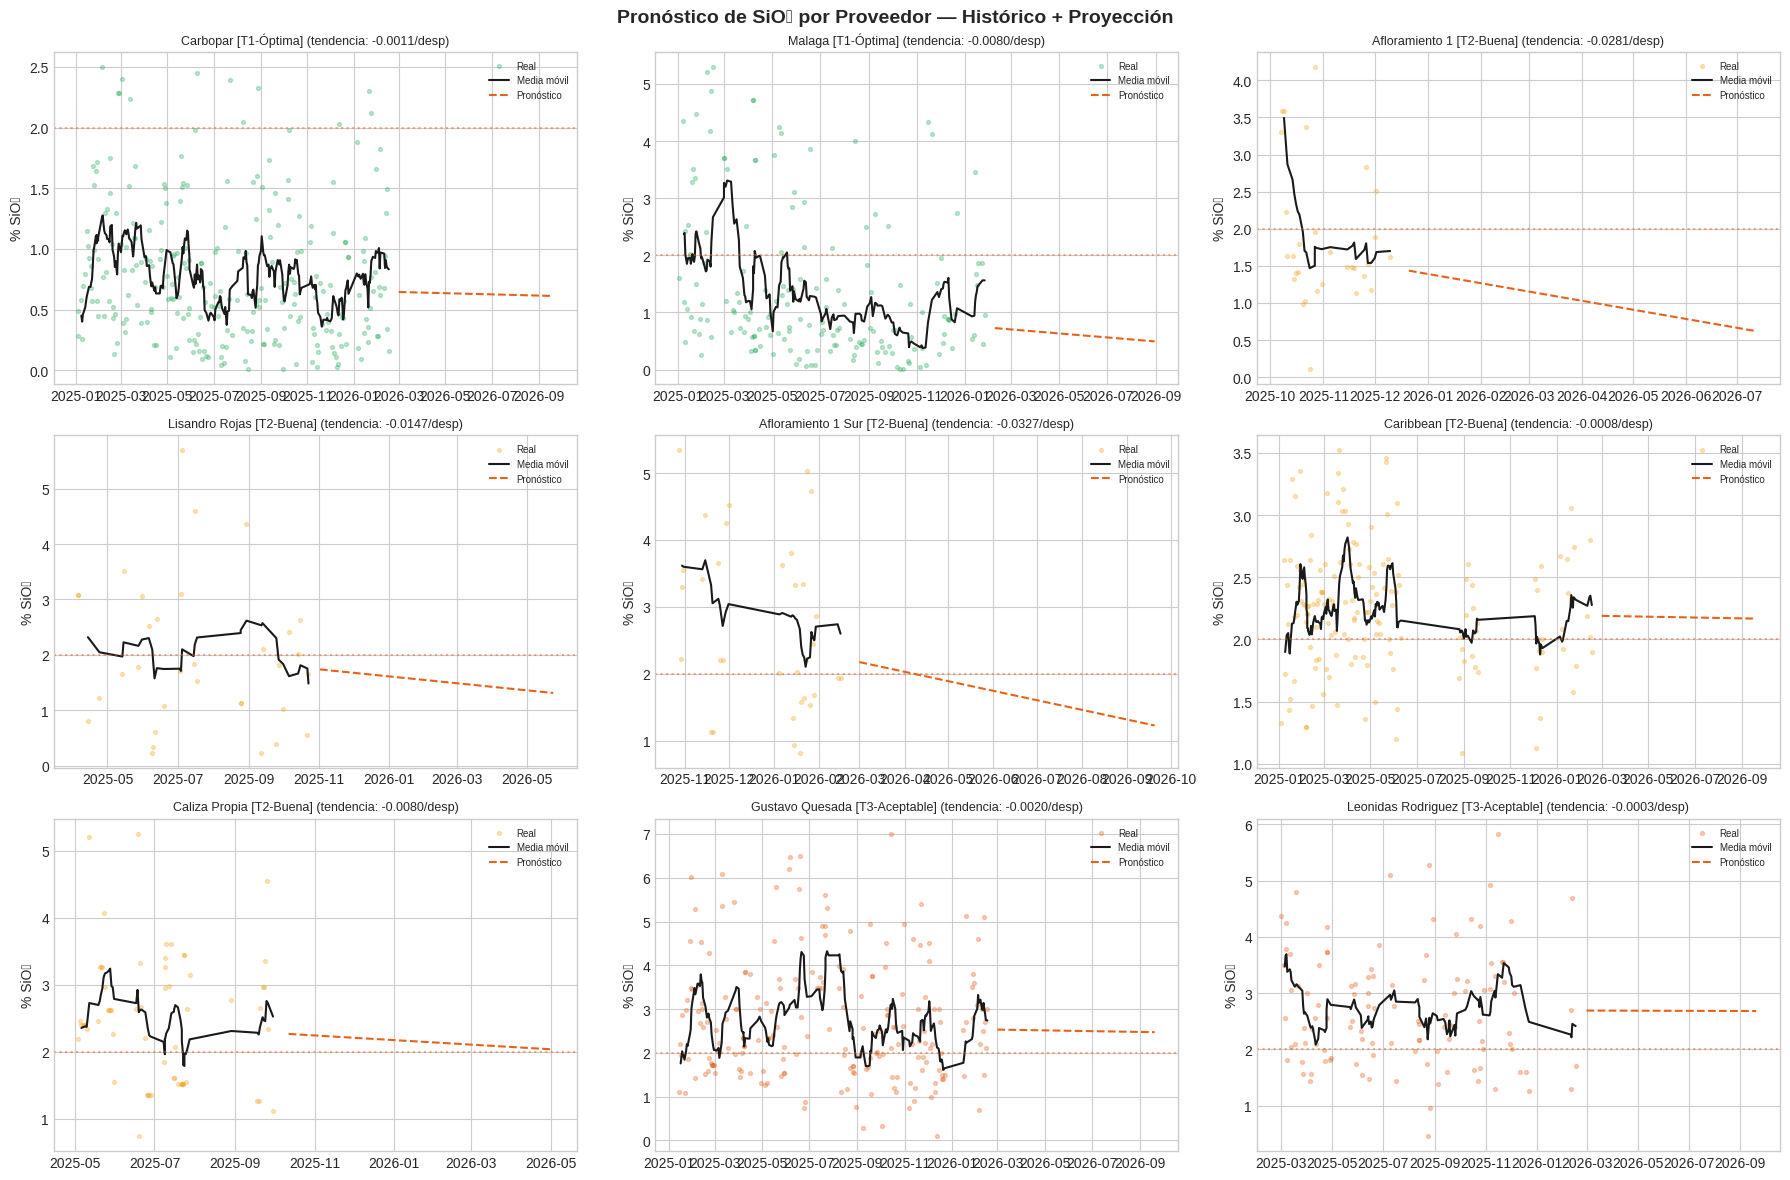

In [12]:
# 7.1 SERIE TEMPORAL + PRONÓSTICO POR PROVEEDOR
top_provs = profiles[profiles['n'] >= 20].index.tolist()  # Solo con suficientes datos
n_provs = len(top_provs)
cols = min(3, n_provs)
rows = (n_provs + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(6*cols, 4*rows), squeeze=False)

for idx, prov in enumerate(top_provs):
    ax = axes[idx//cols][idx%cols]
    grp = df_clean[df_clean['Proveedor']==prov].copy()
    grp = grp.dropna(subset=['Fecha']).sort_values('Fecha')
    if len(grp) < 10:
        ax.set_title(f'{prov} (n={len(grp)}, insuficiente)', fontsize=10)
        continue

    # Media móvil ponderada (ventana 10)
    grp['SiO2_MA'] = grp['SiO2'].rolling(window=10, min_periods=3).mean()

    # Tendencia lineal
    grp['t'] = np.arange(len(grp))
    slope, intercept, r_val, _, _ = stats.linregress(grp['t'], grp['SiO2'])

    # Pronóstico 6 meses (~180 puntos)
    fut_t = np.arange(len(grp), len(grp) + 30)
    fut_vals = intercept + slope * fut_t
    fut_dates = pd.date_range(grp['Fecha'].max(), periods=31, freq='W')[1:]

    tipo = profiles.loc[prov, 'tipo']
    color = TIPO_COLORS.get(tipo, C['g2'])

    ax.scatter(grp['Fecha'], grp['SiO2'], alpha=0.3, s=8, color=color, label='Real')
    ax.plot(grp['Fecha'], grp['SiO2_MA'], color=C['neg'], lw=1.5, label='Media móvil')
    ax.plot(fut_dates[:len(fut_vals)], fut_vals, '--', color=C['nar'], lw=1.5, label='Pronóstico')
    ax.axhline(y=2.0, color=C['nar'], linestyle=':', alpha=0.5)
    ax.set_title(f'{prov} [{tipo}] (tendencia: {slope:+.4f}/desp)', fontsize=9)
    ax.set_ylabel('% SiO₂')
    ax.legend(fontsize=7)

# Ocultar ejes vacíos
for idx in range(n_provs, rows*cols):
    axes[idx//cols][idx%cols].set_visible(False)

plt.suptitle('Pronóstico de SiO₂ por Proveedor — Histórico + Proyección', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 8. 🔄 Combinaciones de Mezcla — Exhaustivo

Se evalúan **todas las combinaciones posibles** de 2, 3 y 4 proveedores
para cada destino, con proporciones optimizadas.

In [ ]:
# 8.1 EVALUAR COMBINACIONES DE MEZCLA
SPECS = {'SÍNTER':{'sio2_max':4.0,'cao_min':50.0},'CALCINACIÓN':{'sio2_max':2.0,'cao_min':52.0}}

def eval_combo(provs, dest, demand=1000):
    """Optimiza proporciones para una combinación específica de proveedores."""
    specs = SPECS[dest]
    n = len(provs)

    def obj(props):
        ps = props / props.sum() if props.sum() > 0 else np.ones(n)/n
        cost = sum(ps[i]*profiles.loc[provs[i],'costo_ton'] for i in range(n))
        sio2 = sum(ps[i]*profiles.loc[provs[i],'sio2_mediana'] for i in range(n))
        cao = sum(ps[i]*profiles.loc[provs[i],'cao_mediana'] for i in range(n))
        pen = 0
        if sio2 > specs['sio2_max']: pen += (sio2-specs['sio2_max'])**2 * 1e6
        if cao < specs['cao_min']: pen += (specs['cao_min']-cao)**2 * 1e6
        return cost + pen

    res = differential_evolution(obj, [(0.01,1)]*n, maxiter=200, seed=42, tol=1e-6)
    opt = res.x / res.x.sum()
    sio2 = sum(opt[i]*profiles.loc[provs[i],'sio2_mediana'] for i in range(n))
    cao = sum(opt[i]*profiles.loc[provs[i],'cao_mediana'] for i in range(n))
    cost = sum(opt[i]*profiles.loc[provs[i],'costo_ton'] for i in range(n))
    meets = sio2 <= specs['sio2_max'] and cao >= specs['cao_min']
    return {'proveedores':list(provs), 'proporciones':opt.tolist(), 'sio2':sio2,
            'cao':cao, 'costo':cost, 'cumple':meets, 'destino':dest}

# Evaluar combos de 2, 3 y 4 proveedores para cada destino
prov_list = profiles.index.tolist()
all_combos = {dest: [] for dest in SPECS}

for dest in SPECS:
    print(f'\nEvaluando combinaciones para {dest}...')
    for size in [2, 3, 4]:
        for combo in combinations(prov_list, size):
            r = eval_combo(combo, dest)
            if r['cumple']:
                all_combos[dest].append(r)
    # Ordenar por costo
    all_combos[dest].sort(key=lambda x: x['costo'])
    n_ok = len(all_combos[dest])
    print(f'  ✓ {n_ok} combinaciones que cumplen especificaciones')
    if n_ok > 0:
        top = all_combos[dest][0]
        print(f'  🏆 Mejor costo: ${top["costo"]:,.0f}/ton | SiO₂={top["sio2"]:.2f}% | {" + ".join(top["proveedores"])}')


Evaluando combinaciones para SÍNTER...


In [ ]:
# 8.2 TOP 10 MEJORES MEZCLAS POR DESTINO
for dest in SPECS:
    print(f'\n{"="*80}')
    print(f'  TOP 10 MEZCLAS — {dest} (SiO₂ ≤ {SPECS[dest]["sio2_max"]}%, CaO ≥ {SPECS[dest]["cao_min"]}%)')
    print(f'{"="*80}')
    print(f'{"#":>3} {"Proveedores":<50} {"SiO₂":>7} {"CaO":>7} {"$/ton":>10}')
    print('─'*80)
    for i, r in enumerate(all_combos[dest][:10]):
        # Formato con proporciones
        parts = [f'{p}({r["proporciones"][j]*100:.0f}%)' for j, p in enumerate(r['proveedores'])]
        label = ' + '.join(parts)
        if len(label) > 48: label = label[:48] + '..'
        print(f'{i+1:>3} {label:<50} {r["sio2"]:>6.2f}% {r["cao"]:>6.1f}% {r["costo"]:>10,.0f}')

In [ ]:
# 8.3 VISUALIZAR TOP 5 MEZCLAS POR DESTINO
for dest in SPECS:
    top5 = all_combos[dest][:5]
    if not top5: continue
    fig = go.Figure()
    for i, r in enumerate(top5):
        label = f'#{i+1}: ${r["costo"]:,.0f}/ton'
        fig.add_trace(go.Bar(
            name=label,
            x=[f'{p[:12]}' for p in r['proveedores']],
            y=[p*100 for p in r['proporciones']],
            text=[f'{p*100:.0f}%' for p in r['proporciones']],
            textposition='auto'
        ))
    fig.update_layout(title=f'Top 5 Mezclas — {dest}', barmode='group',
        yaxis_title='Proporción (%)', height=400, template='plotly_white')
    fig.show()

## 9. 🤖 Comparativa Multi-Modelo (8 modelos)

In [ ]:
# 9.1 PREPARAR DATASET + ENTRENAR
def compute_qi(sio2, cao):
    ppc = min(44.0, cao*0.835)
    s = 100 - max(0,(sio2-1.5))*15 - max(0,(52-cao))*5 - max(0,(42-ppc))*3
    return max(0, min(100, s))

records = []
for prov in df_clean['Proveedor'].unique():
    if prov not in profiles.index: continue
    pr = profiles.loc[prov]
    for _, row in df_clean[df_clean['Proveedor']==prov].iterrows():
        ppc = min(44.0, row['CaO']*0.835)
        records.append({
            'sio2':row['SiO2'],'cao':row['CaO'],'ppc':ppc,'ton':row['TON'],
            'sio2_med':pr['sio2_mediana'],'sio2_iqr':pr['sio2_iqr'],
            'cao_med':pr['cao_mediana'],'n_prov':pr['n'],'costo':pr['costo_ton'],
            'qi': compute_qi(row['SiO2'], row['CaO'])
        })

df_t = pd.DataFrame(records)
FEATS = ['sio2','cao','ppc','ton','sio2_med','sio2_iqr','cao_med','n_prov','costo']
X, y = df_t[FEATS].values, df_t['qi'].values
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = RobustScaler()
Xtr_s, Xte_s = scaler.fit_transform(Xtr), scaler.transform(Xte)

models = {
    'Random Forest': RandomForestRegressor(200,max_depth=12,min_samples_leaf=3,random_state=42,n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(300,max_depth=6,learning_rate=0.05,subsample=0.8,random_state=42),
    'SVR (RBF)': SVR(kernel='rbf',C=10,epsilon=0.1),
    'MLP Neural': MLPRegressor(hidden_layer_sizes=(64,32,16),max_iter=1000,random_state=42,early_stopping=True),
    'ElasticNet': ElasticNet(alpha=0.1,l1_ratio=0.5,random_state=42),
    'KNN (k=7)': KNeighborsRegressor(7,weights='distance'),
    'Ridge': Ridge(alpha=1.0),
}
if HAS_XGB: models['XGBoost'] = XGBRegressor(300,max_depth=6,learning_rate=0.05,subsample=0.8,random_state=42,verbosity=0)

res = {}
Xall_s = scaler.transform(X)
print(f'{"Modelo":<22} {"MAE":>7} {"RMSE":>7} {"R²":>8} {"CV R²":>18}')
print('─'*65)
for nm, m in models.items():
    m.fit(Xtr_s, ytr)
    p = m.predict(Xte_s)
    cv = cross_val_score(m, Xall_s, y, cv=5, scoring='r2')
    res[nm] = {'mae':mean_absolute_error(yte,p),'rmse':np.sqrt(mean_squared_error(yte,p)),
               'r2':r2_score(yte,p),'cv':cv.mean(),'cv_std':cv.std(),'pred':p}
    print(f'{nm:<22} {res[nm]["mae"]:>7.3f} {res[nm]["rmse"]:>7.3f} {res[nm]["r2"]:>8.4f} {cv.mean():>8.4f} ± {cv.std():.4f}')

# Ensemble adaptativo top-3
top3 = sorted(res, key=lambda k: res[k]['r2'], reverse=True)[:3]
r2s = sum(res[m]['r2'] for m in top3)
wts = {m: res[m]['r2']/r2s for m in top3}
ens_p = sum(wts[m]*res[m]['pred'] for m in top3)
res['ENSEMBLE'] = {'mae':mean_absolute_error(yte,ens_p),'rmse':np.sqrt(mean_squared_error(yte,ens_p)),
                   'r2':r2_score(yte,ens_p),'cv':np.nan,'cv_std':np.nan,'pred':ens_p}
print(f'{"ENSEMBLE":<22} {res["ENSEMBLE"]["mae"]:>7.3f} {res["ENSEMBLE"]["rmse"]:>7.3f} {res["ENSEMBLE"]["r2"]:>8.4f}')
print(f'\n🏆 Ensemble: {" + ".join([f"{m}({wts[m]:.2f})" for m in top3])}')

In [ ]:
# 9.2 VISUALIZACIÓN COMPARATIVA
sorted_m = sorted(res, key=lambda k: res[k]['r2'], reverse=True)
colors = [C['nar'] if m=='ENSEMBLE' else C['azul'] for m in sorted_m]

fig = make_subplots(rows=1, cols=2, subplot_titles=['R² por Modelo','MAE por Modelo'])
fig.add_trace(go.Bar(x=sorted_m, y=[res[m]['r2'] for m in sorted_m],
    marker_color=colors, text=[f"{res[m]['r2']:.4f}" for m in sorted_m], textposition='outside'), row=1, col=1)
fig.add_trace(go.Bar(x=sorted_m, y=[res[m]['mae'] for m in sorted_m],
    marker_color=colors, text=[f"{res[m]['mae']:.3f}" for m in sorted_m], textposition='outside'), row=1, col=2)
fig.update_layout(height=450, showlegend=False, template='plotly_white', title_text='Comparativa de Modelos')
fig.update_xaxes(tickangle=-45)
fig.show()

## 10. 🎯 PLANIFICADOR INTERACTIVO DE MEZCLA

**Esta es la herramienta operativa.** Ingresa:
1. Granulometría de caliza a consumir
2. Volumen de producción objetivo (ton/día)
3. Toneladas por proveedor que llegan hoy

El sistema genera el **plan de mezcla óptimo** del día.

In [ ]:
# 10.1 PLANIFICADOR — INGRESO DE DATOS
print('='*60)
print('  PLANIFICADOR DE MEZCLA DE CALIZA — PazdelRío')
print('='*60)

# --- Parámetros de producción ---
print('\n📋 PARÁMETROS DE PRODUCCIÓN:')
granulometria = input('  Granulometría a consumir (ej: <3mm, <10mm, <50mm): ') or '<3mm'
ton_sinter = float(input('  Toneladas necesarias para SÍNTER hoy: ') or 400)
ton_calc = float(input('  Toneladas necesarias para CALCINACIÓN hoy: ') or 150)
ton_ah = float(input('  Toneladas para ALTO HORNO directo (0 si no aplica): ') or 0)

# --- Llegadas del día ---
print(f'\n🚛 LLEGADAS DE CALIZA HOY (ton por proveedor):')
print('  (Escribe 0 si el proveedor no despacha hoy)\n')
llegadas = {}
for prov in profiles.index:
    tipo = profiles.loc[prov, 'tipo']
    sio2 = profiles.loc[prov, 'sio2_mediana']
    val = input(f'  {prov:<22} [{tipo}, SiO₂={sio2:.2f}%]: ') or '0'
    val = float(val)
    if val > 0:
        llegadas[prov] = val

print(f'\n✓ Configuración:')
print(f'  Granulometría: {granulometria}')
print(f'  Demanda: Sínter={ton_sinter:.0f} ton | Calcinación={ton_calc:.0f} ton | Alto Horno={ton_ah:.0f} ton')
print(f'  Llegadas: {sum(llegadas.values()):.0f} ton de {len(llegadas)} proveedores')
for p, t in llegadas.items():
    print(f'    {p}: {t:.0f} ton')

In [ ]:
# 10.2 OPTIMIZACIÓN CON RESTRICCIONES DE DISPONIBILIDAD REAL
def plan_mezcla(llegadas, demand, dest, specs):
    """Optimiza mezcla con restricción de disponibilidad real del día."""
    provs = list(llegadas.keys())
    tons_disp = np.array([llegadas[p] for p in provs])
    n = len(provs)
    if n == 0 or sum(tons_disp) == 0:
        return None

    def objective(tons):
        total = tons.sum()
        if total == 0: return 1e12
        props = tons / total
        sio2 = sum(props[i]*profiles.loc[provs[i],'sio2_mediana'] for i in range(n))
        cao = sum(props[i]*profiles.loc[provs[i],'cao_mediana'] for i in range(n))
        cost = sum(tons[i]*profiles.loc[provs[i],'costo_ton'] for i in range(n))
        penalty = 0
        if sio2 > specs['sio2_max']: penalty += (sio2-specs['sio2_max'])**2 * 1e8
        if cao < specs['cao_min']: penalty += (specs['cao_min']-cao)**2 * 1e8
        penalty += abs(total - demand) * 1e5  # Penalizar desviación de demanda
        return cost + penalty

    # Bounds: 0 a la disponibilidad de cada proveedor
    bounds = [(0, min(t, demand)) for t in tons_disp]
    res = differential_evolution(objective, bounds, maxiter=300, seed=42, polish=True)
    tons_opt = res.x
    total = tons_opt.sum()
    if total == 0: return None

    props = tons_opt / total
    sio2 = sum(props[i]*profiles.loc[provs[i],'sio2_mediana'] for i in range(n))
    cao = sum(props[i]*profiles.loc[provs[i],'cao_mediana'] for i in range(n))
    cost = sum(tons_opt[i]*profiles.loc[provs[i],'costo_ton'] for i in range(n))

    plan = []
    for i in range(n):
        if tons_opt[i] > 0.5:  # Mínimo 0.5 ton
            plan.append({
                'proveedor': provs[i],
                'tipo': profiles.loc[provs[i],'tipo'],
                'ton_disponible': tons_disp[i],
                'ton_asignada': tons_opt[i],
                'proporcion': props[i],
                'sio2': profiles.loc[provs[i],'sio2_mediana'],
                'cao': profiles.loc[provs[i],'cao_mediana'],
                'costo_parcial': tons_opt[i]*profiles.loc[provs[i],'costo_ton'],
            })

    return {'destino': dest, 'demanda': demand, 'plan': plan,
            'sio2_mezcla': sio2, 'cao_mezcla': cao, 'costo_total': cost,
            'ton_total': total, 'cumple': sio2<=specs['sio2_max'] and cao>=specs['cao_min']}

# Ejecutar para cada destino
planes = []
destinos = []
if ton_sinter > 0: destinos.append(('SÍNTER', ton_sinter, SPECS['SÍNTER']))
if ton_calc > 0: destinos.append(('CALCINACIÓN', ton_calc, SPECS['CALCINACIÓN']))
if ton_ah > 0: destinos.append(('ALTO HORNO', ton_ah, {'sio2_max':3.0,'cao_min':51.0}))

# Asignar caliza disponible secuencialmente (calcinación primero por ser más restrictivo)
destinos.sort(key=lambda x: x[2]['sio2_max'])  # Más restrictivo primero
disponible = dict(llegadas)  # Copia de disponibilidad

for dest, demand, specs in destinos:
    # Usar solo lo disponible
    disp_actual = {p: t for p, t in disponible.items() if t > 0}
    plan = plan_mezcla(disp_actual, demand, dest, specs)
    if plan:
        planes.append(plan)
        # Descontar tonelaje asignado
        for item in plan['plan']:
            disponible[item['proveedor']] -= item['ton_asignada']
            disponible[item['proveedor']] = max(0, disponible[item['proveedor']])

print('Planes calculados:', len(planes))

In [ ]:
# 10.3 REPORTE DEL PLAN DE MEZCLA DEL DÍA
print('\n' + '█'*60)
print(f'  PLAN DE MEZCLA — {datetime.now().strftime("%d/%m/%Y")}')
print(f'  Granulometría: {granulometria}')
print('█'*60)

costo_dia_total = 0
for plan in planes:
    st = '✓ CUMPLE' if plan['cumple'] else '⚠ NO CUMPLE'
    print(f'\n┌{"─"*58}┐')
    print(f'│  {plan["destino"]:<20} {st:>20}  Demanda: {plan["demanda"]:,.0f} ton │')
    print(f'├{"─"*58}┤')
    print(f'│  {"Proveedor":<18} {"Tipo":<14} {"Ton":>7} {"  %":>5} {"SiO₂":>6} │')
    print(f'│  {"─"*52} │')
    for item in sorted(plan['plan'], key=lambda x: x['ton_asignada'], reverse=True):
        print(f'│  {item["proveedor"]:<18} {item["tipo"]:<14} {item["ton_asignada"]:>7.0f} {item["proporcion"]*100:>4.0f}% {item["sio2"]:>5.2f}% │')
    print(f'├{"─"*58}┤')
    print(f'│  MEZCLA:  SiO₂ = {plan["sio2_mezcla"]:>5.2f}%  │  CaO = {plan["cao_mezcla"]:>5.1f}%              │')
    print(f'│  COSTO:   ${plan["costo_total"]:>12,.0f}  │  Total: {plan["ton_total"]:>7.0f} ton            │')
    print(f'└{"─"*58}┘')
    costo_dia_total += plan['costo_total']

# Resumen de disponibilidad restante
print(f'\n📦 CALIZA RESTANTE SIN ASIGNAR:')
for p, t in disponible.items():
    if t > 0.5:
        print(f'  {p}: {t:.0f} ton (almacenar en patio)')

print(f'\n💰 COSTO TOTAL DEL DÍA: ${costo_dia_total:,.0f}')

In [ ]:
# 10.4 VISUALIZACIÓN DEL PLAN
if planes:
    fig = make_subplots(rows=1, cols=len(planes), specs=[[{'type':'pie'}]*len(planes)],
        subplot_titles=[f'{p["destino"]} ({p["ton_total"]:.0f} ton)' for p in planes])
    for i, plan in enumerate(planes):
        labels = [f'{it["proveedor"]}\n[{it["tipo"]}]' for it in plan['plan']]
        values = [it['ton_asignada'] for it in plan['plan']]
        colors_pie = [TIPO_COLORS.get(it['tipo'], C['g2']) for it in plan['plan']]
        fig.add_trace(go.Pie(labels=labels, values=values, marker=dict(colors=colors_pie),
            textinfo='label+percent', hole=0.35), row=1, col=i+1)
    fig.update_layout(height=400, template='plotly_white',
        title_text=f'Plan de Mezcla del Día — Costo Total: ${costo_dia_total:,.0f}')
    fig.show()

## 11. 💾 Exportar Resultados

In [ ]:
with pd.ExcelWriter('plan_mezcla_caliza_v3.xlsx', engine='openpyxl') as w:
    profiles.to_excel(w, sheet_name='Perfiles_Proveedores')
    df_clean.to_excel(w, sheet_name='Datos_Limpios', index=False)
    pd.DataFrame(res).T[['mae','rmse','r2','cv']].to_excel(w, sheet_name='Modelos')
    # Plan del día
    plan_rows = []
    for plan in planes:
        for it in plan['plan']:
            plan_rows.append({**it, 'destino':plan['destino'], 'cumple':plan['cumple']})
    if plan_rows:
        pd.DataFrame(plan_rows).to_excel(w, sheet_name='Plan_Mezcla_Dia', index=False)
    # Mejores combos
    for dest in all_combos:
        if all_combos[dest]:
            rows = [{'proveedores':'+'.join(r['proveedores']),
                     **{f'prop_{i}':p for i,p in enumerate(r['proporciones'])},
                     'sio2':r['sio2'],'cao':r['cao'],'costo':r['costo']}
                    for r in all_combos[dest][:20]]
            pd.DataFrame(rows).to_excel(w, sheet_name=f'Top20_{dest[:6]}', index=False)

print('✓ Exportado: plan_mezcla_caliza_v3.xlsx')
try:
    from google.colab import files
    files.download('plan_mezcla_caliza_v3.xlsx')
except: pass

---
## ✅ Capacidades del Sistema v3

| Capacidad | Estado |
|---|---|
| Limpieza con fusión de duplicados | ✓ |
| Outliers IQR por proveedor + visualización antes/después | ✓ |
| Monte Carlo 500 datos/proveedor (ajuste distribución) | ✓ |
| Pronóstico temporal por proveedor | ✓ |
| Clasificación T1/T2/T3/T4 con bootstrap CI 95% | ✓ |
| Combinaciones exhaustivas de mezcla (2,3,4 proveedores) | ✓ |
| Comparativa 8 modelos ML + Ensemble adaptativo | ✓ |
| **Planificador interactivo con llegadas del día** | ✓ |

---
*Acerías Paz del Río S.A. — DD-PDR-GES-003 MASP v3.0 — 2026*